In [31]:
from pathlib import Path
import sqlite3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


In [32]:
PROJECT_ROOT = Path.cwd().parent

DATABASE = PROJECT_ROOT / "data" / "healthcare_claims.db"

conn = sqlite3.connect(DATABASE)

claims = pd.read_sql(
    "SELECT * FROM claims",
    conn
)

conn.close()

claims.head()

,claim_id,patient_id,provider_id,submission_date,payer_name,plan_type,provider_specialty,cpt_code,icd10_code,claim_amount,...,provider_credentialed,coding_valid,duplicate_indicator,days_to_submit,claim_status,was_denied,denial_reason,amount_paid,revenue_leakage,denial_probability_true
0,CLM0000001,PAT000298,PRV0051,2025-01-13,Aetna Commercial,Commercial,Dermatology,70553,M17.11,729.58,...,1,1,0,12,Approved,0,Not Denied,678.74,50.84,0.0339
1,CLM0000002,PAT002579,PRV0033,2025-09-21,BlueShield Commercial,Commercial,Dermatology,99214,M17.11,1119.21,...,1,1,0,6,Approved,0,Not Denied,728.30,390.91,0.0373
2,CLM0000003,PAT002182,PRV0079,2025-03-20,Aetna Commercial,Commercial,Gastroenterology,93000,I10,2959.21,...,1,1,0,5,Approved,0,Not Denied,2104.22,854.99,0.0392
3,CLM0000004,PAT001463,PRV0100,2025-09-17,State Medicaid,Medicaid,Orthopedics,99214,I10,5848.79,...,1,1,0,7,Approved,0,Not Denied,4958.09,890.70,0.0794
4,CLM0000005,PAT001443,PRV0040,2025-07-26,Humana Medicare Advantage,Medicare Advantage,Orthopedics,71046,E11.9,5646.59,...,1,1,0,7,Denied,1,Medical Necessity / Other,0.00,5646.59,0.0660


In [33]:
features = [
    "payer_name",
    "plan_type",
    "provider_specialty",
    "cpt_code",
    "icd10_code",
    "claim_amount",
    "prior_auth_required",
    "prior_auth_on_file",
    "documentation_complete",
    "eligibility_verified",
    "provider_credentialed",
    "coding_valid",
    "duplicate_indicator",
    "days_to_submit"
]

X = claims[features]

y = claims["was_denied"]

In [34]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [35]:
X.head()

,cpt_code,claim_amount,prior_auth_required,prior_auth_on_file,documentation_complete,eligibility_verified,provider_credentialed,coding_valid,duplicate_indicator,days_to_submit,...,provider_specialty_Orthopedics,provider_specialty_Primary Care,provider_specialty_Radiology,icd10_code_G43.909,icd10_code_I10,icd10_code_K21.9,icd10_code_L30.9,icd10_code_M17.11,icd10_code_R07.9,icd10_code_Z00.00
0,70553,729.58,1,1,1,1,1,1,0,12,...,False,False,False,False,False,False,False,True,False,False
1,99214,1119.21,0,1,1,1,1,1,0,6,...,False,False,False,False,False,False,False,True,False,False
2,93000,2959.21,0,1,1,1,1,1,0,5,...,False,False,False,False,True,False,False,False,False,False
3,99214,5848.79,1,1,1,1,1,1,0,7,...,True,False,False,False,True,False,False,False,False,False
4,71046,5646.59,1,1,1,1,1,1,0,7,...,True,False,False,False,False,False,False,False,False,False


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)


model.fit(
    X_train,
    y_train
)

/Users/simmi/Downloads/healthcare-claim-denial-analytics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [38]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:, 1]

In [39]:
print("Accuracy")

print(
    accuracy_score(
        y_test,
        predictions
    )
)

print()

print("ROC-AUC")

print(
    roc_auc_score(
        y_test,
        probabilities
    )
)

Accuracy
0.7495

ROC-AUC
0.782787660108565


In [40]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

In [41]:
print(f"Accuracy: {accuracy_score(y_test, predictions):.3f}")

Accuracy: 0.750


In [42]:
print(f"Precision: {precision_score(y_test, predictions):.3f}")

Precision: 0.290


In [43]:
print(f"Recall: {recall_score(y_test, predictions):.3f}")

Recall: 0.685


In [44]:
print(f"F1 Score: {f1_score(y_test, predictions):.3f}")

F1 Score: 0.407


In [45]:
print(f"ROC AUC: {roc_auc_score(y_test, probabilities):.3f}")

ROC AUC: 0.783


In [46]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      1749
           1       0.29      0.69      0.41       251

    accuracy                           0.75      2000
   macro avg       0.62      0.72      0.62      2000
weighted avg       0.86      0.75      0.79      2000



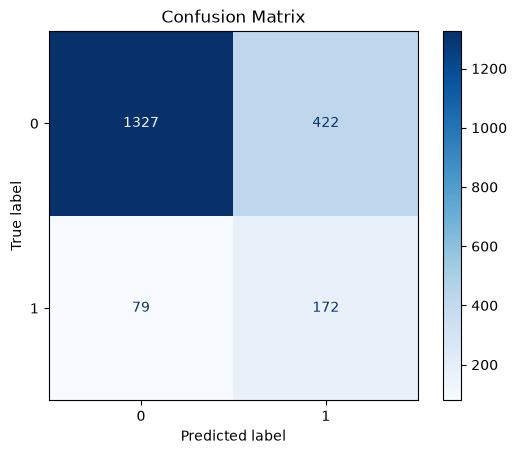

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

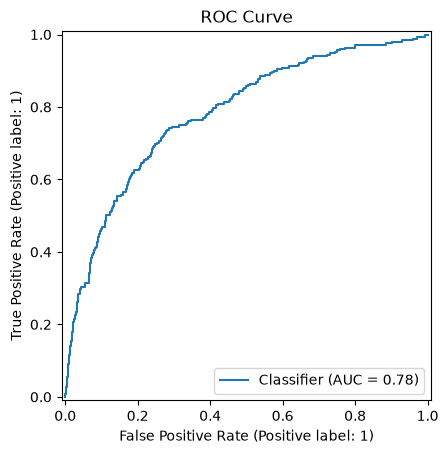

In [48]:
RocCurveDisplay.from_predictions(
    y_test,
    probabilities
)

plt.title("ROC Curve")
plt.show()

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute
8,duplicate_indicator,2.350800,2.350800
3,prior_auth_on_file,-2.139054,2.139054
10,payer_name_Ambetter Marketplace,1.798307,1.798307
6,provider_credentialed,-1.494557,1.494557
4,documentation_complete,-1.471326,1.471326
7,coding_valid,-1.230110,1.230110
5,eligibility_verified,-1.172239,1.172239
14,plan_type_Commercial,1.086996,1.086996
15,plan_type_Medicaid,0.834826,0.834826
13,payer_name_State Medicaid,0.834826,0.834826


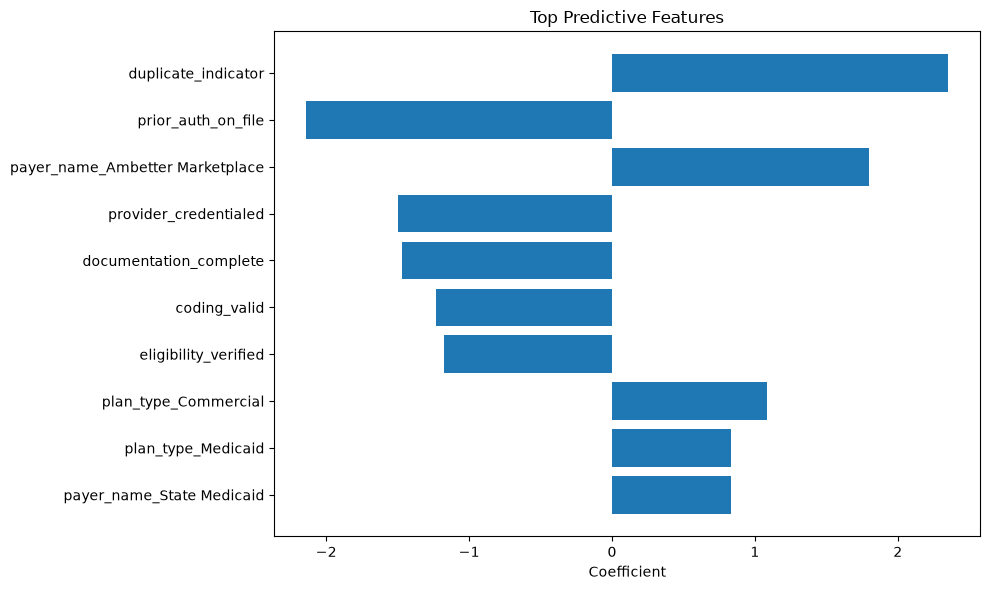

In [50]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Predictive Features")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [51]:
MODEL_PATH = PROJECT_ROOT / "models" / "claim_denial_model.pkl"
FEATURE_COLUMNS_PATH = PROJECT_ROOT / "models" / "feature_columns.pkl"

joblib.dump(model, MODEL_PATH)
joblib.dump(X.columns.tolist(), FEATURE_COLUMNS_PATH)

print(f"Model saved to: {MODEL_PATH}")
print(f"Feature columns saved to: {FEATURE_COLUMNS_PATH}")

Model saved to: /Users/simmi/Downloads/healthcare-claim-denial-analytics/models/claim_denial_model.pkl
Feature columns saved to: /Users/simmi/Downloads/healthcare-claim-denial-analytics/models/feature_columns.pkl


In [52]:
%pip install joblib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
